# STEP 1:The initial check and cleaning of Data

In [1275]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [1276]:
#Read Data
df=pd.read_csv(r"C:\Users\user\Downloads\day.csv")

In [1277]:
#To check columns present in dataset
print(df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [1278]:
df.shape

(730, 16)

In [1279]:
#Get basic idea of data using describe()
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [1280]:
#Checking for null values in dataset

count=df.isnull().sum()
print(count)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [1281]:
#There are no missing values in the dataset

In [1282]:
df['dteday'].dtype

dtype('O')

Let's convert the datatype of dteday column to datetime

In [1283]:
df['dteday'] =  pd.to_datetime(df['dteday'],format='%d-%m-%Y')
df['dteday'].dtype

dtype('<M8[ns]')

In [1284]:
#Checking for datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     730 non-null    int64         
 1   dteday      730 non-null    datetime64[ns]
 2   season      730 non-null    int64         
 3   yr          730 non-null    int64         
 4   mnth        730 non-null    int64         
 5   holiday     730 non-null    int64         
 6   weekday     730 non-null    int64         
 7   workingday  730 non-null    int64         
 8   weathersit  730 non-null    int64         
 9   temp        730 non-null    float64       
 10  atemp       730 non-null    float64       
 11  hum         730 non-null    float64       
 12  windspeed   730 non-null    float64       
 13  casual      730 non-null    int64         
 14  registered  730 non-null    int64         
 15  cnt         730 non-null    int64         
dtypes: datetime64[ns](1), floa

In [1285]:
#From the given data we can see that instant is an index column so it is dropped
df.drop(['instant'],axis=1,inplace=True)

In [1286]:
df.head(100)

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2018-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2018-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,2018-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,2018-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,2018-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2018-04-06,2,0,4,0,3,1,1,16.024153,19.38040,47.0833,17.625221,413,2395,2808
96,2018-04-07,2,0,4,0,4,1,1,17.937500,21.68480,60.2917,10.874904,571,2570,3141
97,2018-04-08,2,0,4,0,5,1,2,13.769153,16.22395,83.6250,15.208464,172,1299,1471
98,2018-04-09,2,0,4,0,6,0,2,14.042500,17.07645,87.7500,8.916561,879,1576,2455


In [1287]:
df['year'] = pd.DatetimeIndex(df['dteday']).year
df['month'] = pd.DatetimeIndex(df['dteday']).month

In [1288]:
df.head(100)

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month
0,2018-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985,2018,1
1,2018-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801,2018,1
2,2018-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349,2018,1
3,2018-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562,2018,1
4,2018-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600,2018,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2018-04-06,2,0,4,0,3,1,1,16.024153,19.38040,47.0833,17.625221,413,2395,2808,2018,4
96,2018-04-07,2,0,4,0,4,1,1,17.937500,21.68480,60.2917,10.874904,571,2570,3141,2018,4
97,2018-04-08,2,0,4,0,5,1,2,13.769153,16.22395,83.6250,15.208464,172,1299,1471,2018,4
98,2018-04-09,2,0,4,0,6,0,2,14.042500,17.07645,87.7500,8.916561,879,1576,2455,2018,4


In [1289]:
# Dropping the columns as we have extracte#d the correct year and month from the date.
df.drop(['yr','mnth','dteday'],axis=1,inplace=True)

In [1290]:
#We know that casual+registered=cnt and cnt is our target variable so we will not consider casual and registered
df.drop(['casual','registered'],axis=1,inplace=True)
df.head()

#Dropping the redundant variable holiday as the workingday column covers enough information that is required.
df.drop('holiday',axis=1,inplace=True)

In [1291]:
#Check for datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    int64  
 1   weekday     730 non-null    int64  
 2   workingday  730 non-null    int64  
 3   weathersit  730 non-null    int64  
 4   temp        730 non-null    float64
 5   atemp       730 non-null    float64
 6   hum         730 non-null    float64
 7   windspeed   730 non-null    float64
 8   cnt         730 non-null    int64  
 9   year        730 non-null    int64  
 10  month       730 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB


# Step 2: Encoding the Labels & Visualization

1) season
1:spring
2:summer
3:fall
4:winter

From the data it can be see that: season,yr,mnth,holiday,weekday,workingday,weathersit all are categorical variables
We will replace season,weekday and weathersit with appropriate values

In [1292]:
df['season'].replace({1:"spring",2:"summer",3:"fall",4:"winter"},inplace=True)
df.head(10)

,season,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,year,month
0,spring,6,0,2,14.110847,18.18125,80.5833,10.749882,985,2018,1
1,spring,0,0,2,14.902598,17.68695,69.6087,16.652113,801,2018,1
2,spring,1,1,1,8.050924,9.47025,43.7273,16.636703,1349,2018,1
3,spring,2,1,1,8.200000,10.60610,59.0435,10.739832,1562,2018,1
4,spring,3,1,1,9.305237,11.46350,43.6957,12.522300,1600,2018,1
5,spring,4,1,1,8.378268,11.66045,51.8261,6.000868,1606,2018,1
6,spring,5,1,2,8.057402,10.44195,49.8696,11.304642,1510,2018,1
7,spring,6,0,2,6.765000,8.11270,53.5833,17.875868,959,2018,1
8,spring,0,0,1,5.671653,5.80875,43.4167,24.250650,822,2018,1
9,spring,1,1,1,6.184153,7.54440,48.2917,14.958889,1321,2018,1


2) weathersit
1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog


<AxesSubplot:xlabel='season', ylabel='cnt'>

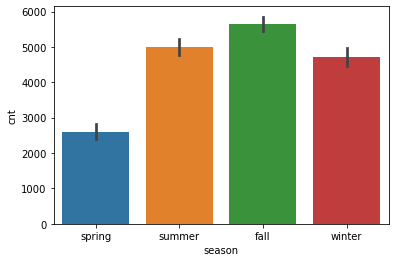

In [1293]:
codes = {1:'Clear',2:'Mist',3:'Light Snow',4:'Heavy Rain'}
df['weathersit'] = df['weathersit'].map(codes)

sns.barplot('season','cnt',data=df)

3) workingday¶
if day is neither weekend nor holiday is 1,
otherwise is 0

<AxesSubplot:xlabel='workingday', ylabel='cnt'>

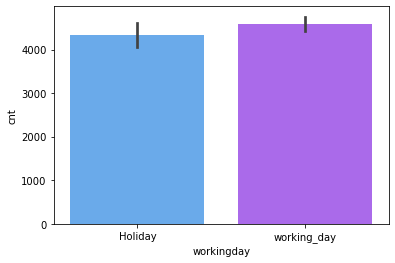

In [1294]:
codes = {1:'working_day',0:'Holiday'}
df['workingday'] = df['workingday'].map(codes)

sns.barplot('workingday','cnt',data=df,palette='cool')

4) year
2018:0
2019:1

In [1295]:
codes = {2019:1,2018:0}
df['year'] = df['year'].map(codes)


In [ ]:

sns.barplot('Year','cnt',data=df,palette='cool')

In [1296]:
df.head(1000)

,season,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,year,month
0,spring,6,Holiday,Mist,14.110847,18.18125,80.5833,10.749882,985,0,1
1,spring,0,Holiday,Mist,14.902598,17.68695,69.6087,16.652113,801,0,1
2,spring,1,working_day,Clear,8.050924,9.47025,43.7273,16.636703,1349,0,1
3,spring,2,working_day,Clear,8.200000,10.60610,59.0435,10.739832,1562,0,1
4,spring,3,working_day,Clear,9.305237,11.46350,43.6957,12.522300,1600,0,1
...,...,...,...,...,...,...,...,...,...,...,...
725,spring,4,working_day,Mist,10.420847,11.33210,65.2917,23.458911,2114,1,12
726,spring,5,working_day,Mist,10.386653,12.75230,59.0000,10.416557,3095,1,12
727,spring,6,Holiday,Mist,10.386653,12.12000,75.2917,8.333661,1341,1,12
728,spring,0,Holiday,Clear,10.489153,11.58500,48.3333,23.500518,1796,1,12


5) Month
1:Jan
2:Feb
3:Mar
4:Apr
5:May
6:June
7:July
8:Aug
9:Sep
10:Oct
11:Nov
12:Dec

<AxesSubplot:xlabel='month', ylabel='cnt'>

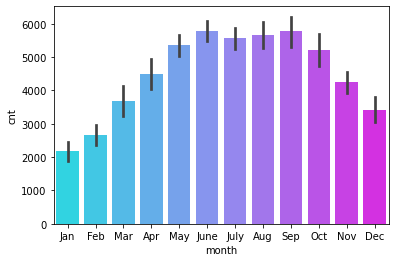

In [1297]:
codes = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['month'] = df['month'].map(codes)

sns.barplot('month','cnt',data=df,palette='cool')
# plt.figure(figsize=(10,5))
# sns.barplot('month','cnt',hue='year',data=df,palette='Paired')

In [1298]:
df.head(10)

,season,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,year,month
0,spring,6,Holiday,Mist,14.110847,18.18125,80.5833,10.749882,985,0,Jan
1,spring,0,Holiday,Mist,14.902598,17.68695,69.6087,16.652113,801,0,Jan
2,spring,1,working_day,Clear,8.050924,9.47025,43.7273,16.636703,1349,0,Jan
3,spring,2,working_day,Clear,8.200000,10.60610,59.0435,10.739832,1562,0,Jan
4,spring,3,working_day,Clear,9.305237,11.46350,43.6957,12.522300,1600,0,Jan
5,spring,4,working_day,Clear,8.378268,11.66045,51.8261,6.000868,1606,0,Jan
6,spring,5,working_day,Mist,8.057402,10.44195,49.8696,11.304642,1510,0,Jan
7,spring,6,Holiday,Mist,6.765000,8.11270,53.5833,17.875868,959,0,Jan
8,spring,0,Holiday,Clear,5.671653,5.80875,43.4167,24.250650,822,0,Jan
9,spring,1,working_day,Clear,6.184153,7.54440,48.2917,14.958889,1321,0,Jan


6) WeekDay:
0:Mon
1:Tue
2:Wed
3:Thu
4:Fri
5:Sat
6:Sun

<AxesSubplot:xlabel='weekday', ylabel='cnt'>

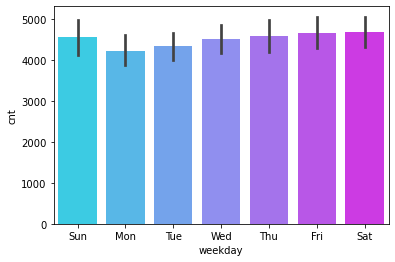

In [1299]:
codes = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df['weekday'] = df['weekday'].map(codes)

sns.barplot('weekday','cnt',data=df,palette='cool')

In [1314]:
df.head(10)

,season,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,year,month
0,spring,Sun,Holiday,Mist,14.110847,18.18125,80.5833,10.749882,985,0,Jan
1,spring,Mon,Holiday,Mist,14.902598,17.68695,69.6087,16.652113,801,0,Jan
2,spring,Tue,working_day,Clear,8.050924,9.47025,43.7273,16.636703,1349,0,Jan
3,spring,Wed,working_day,Clear,8.200000,10.60610,59.0435,10.739832,1562,0,Jan
4,spring,Thu,working_day,Clear,9.305237,11.46350,43.6957,12.522300,1600,0,Jan
5,spring,Fri,working_day,Clear,8.378268,11.66045,51.8261,6.000868,1606,0,Jan
6,spring,Sat,working_day,Mist,8.057402,10.44195,49.8696,11.304642,1510,0,Jan
7,spring,Sun,Holiday,Mist,6.765000,8.11270,53.5833,17.875868,959,0,Jan
8,spring,Mon,Holiday,Clear,5.671653,5.80875,43.4167,24.250650,822,0,Jan
9,spring,Tue,working_day,Clear,6.184153,7.54440,48.2917,14.958889,1321,0,Jan


Bike Rentals are maximum on Sunday and Saturday

7) temp

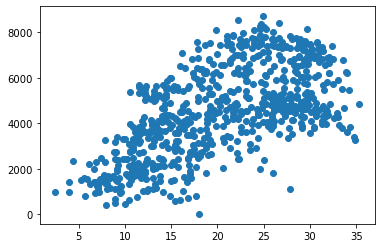

In [1300]:
plt.scatter('temp','cnt',data=df)

Bike Rentals are observed at higher temperatures

8) atemp

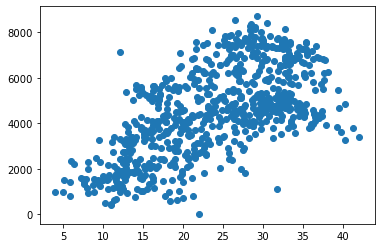

In [1301]:
plt.scatter('atemp','cnt',data=df)

Bike Rentals are observed at higher "feel-like" temperatures.

9) Humidity

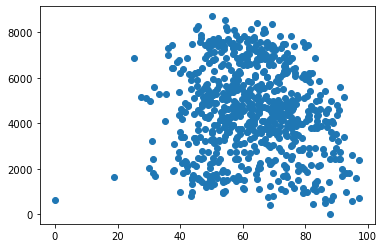

In [1302]:
plt.scatter('hum','cnt',data=df)

Temperature being directly proportional to Humidity, Bike Rentals are making during high humidity

10) Windspeed

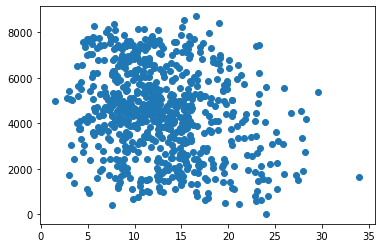

In [1303]:
plt.scatter('windspeed','cnt',data=df)

Wind speeds increase with a greater temperature difference.Wind speed near the surface is most highly correlated with the temperature.

<AxesSubplot:xlabel='cnt', ylabel='Density'>

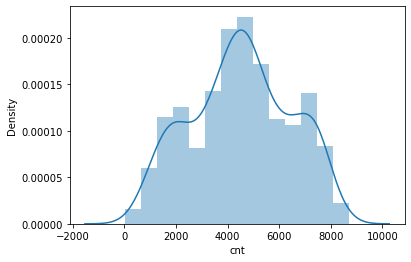

In [1304]:
sns.distplot(df['cnt'])

# Step 3: Visualizing the Relationship among variables

In [1305]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    object 
 1   weekday     730 non-null    object 
 2   workingday  730 non-null    object 
 3   weathersit  730 non-null    object 
 4   temp        730 non-null    float64
 5   atemp       730 non-null    float64
 6   hum         730 non-null    float64
 7   windspeed   730 non-null    float64
 8   cnt         730 non-null    int64  
 9   year        730 non-null    int64  
 10  month       730 non-null    object 
dtypes: float64(4), int64(2), object(5)
memory usage: 62.9+ KB


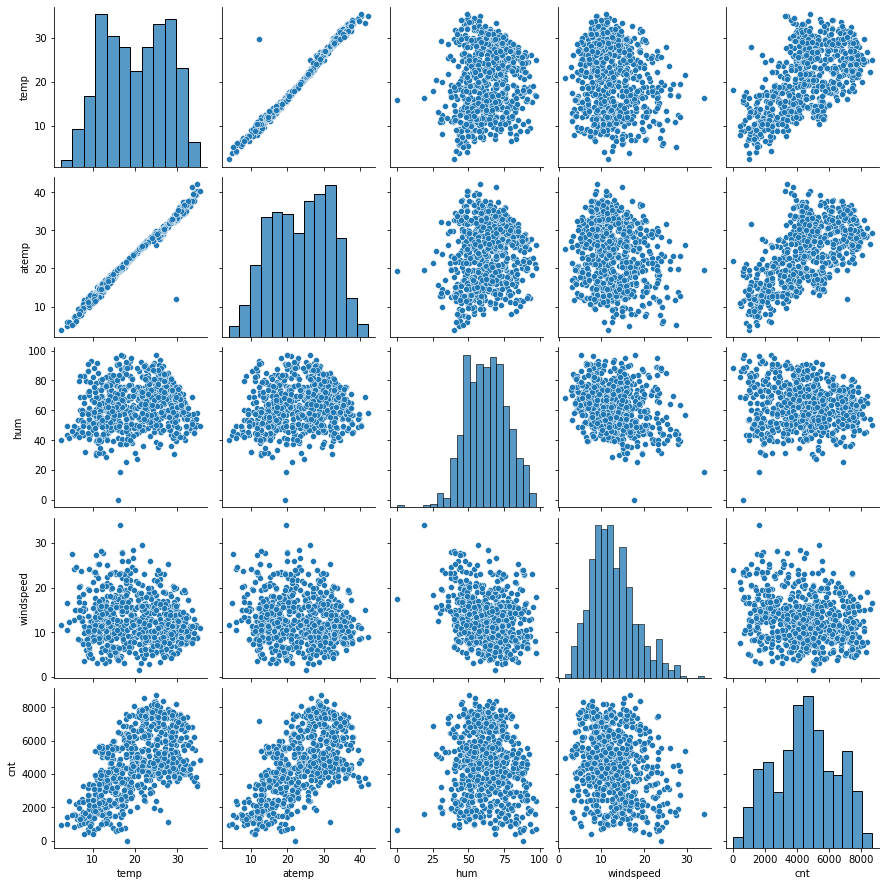

In [1306]:
#Performing EDA
# 1)PAIRPLOTS TO UNDERSTAND NUMERICAL VARIABLES
sns.pairplot(df, vars=['temp','atemp','hum','windspeed',"cnt"])
plt.show()

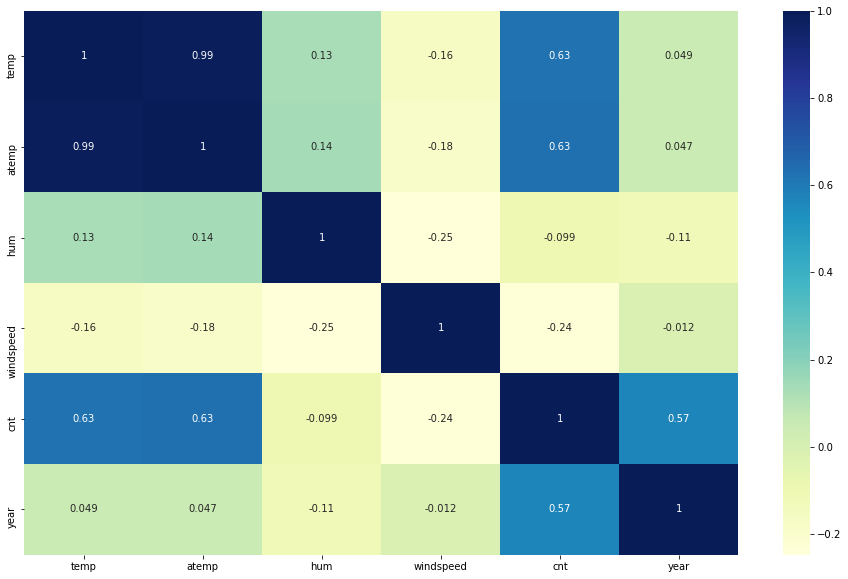

In [1307]:
# From above graphs we can say that temp and atemp have a relationship
#let check the correlation
plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), annot = True, cmap="YlGnBu")
plt.show()

<AxesSubplot:>

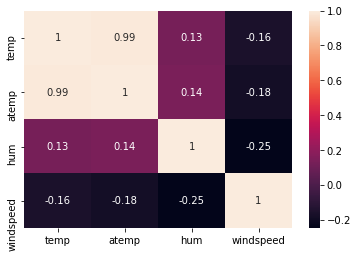

In [1308]:
data= df[['temp','atemp','hum','windspeed']]
sns.heatmap(data.corr(),annot=True)

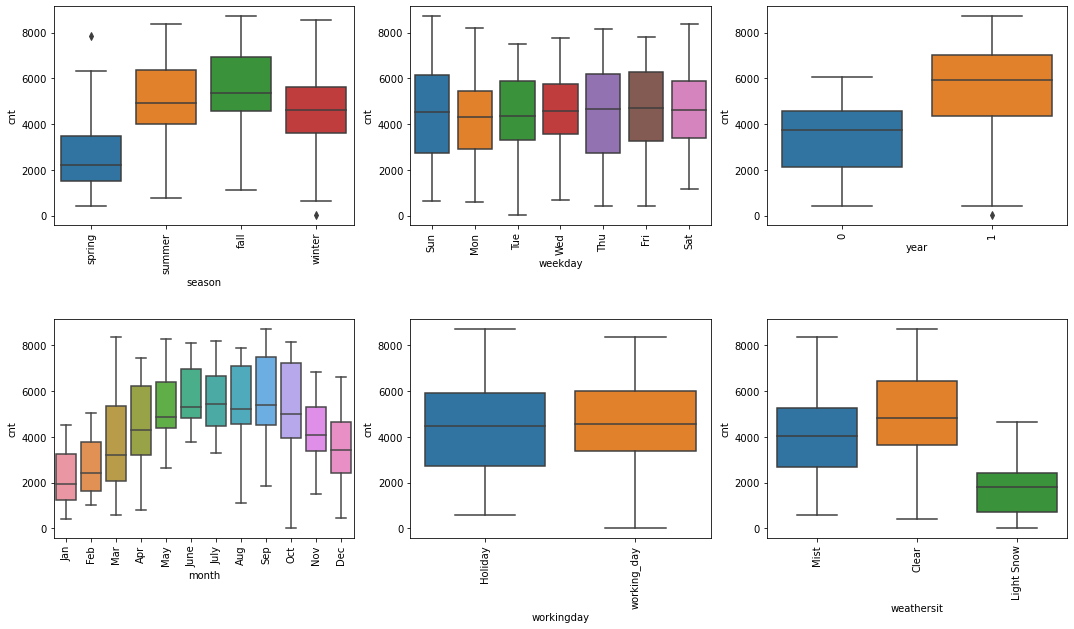

In [1313]:
# identify categorical variables
cat_vars = ['season','weekday','year','month' ,'workingday','weathersit']
# Box plot for categorical variables
col = 3
row = len(cat_vars)//col+1

plt.figure(figsize=(15,12))
for i in list(enumerate(cat_vars)):
    plt.subplot(row,col,i[0]+1)
    sns.boxplot(x = i[1], y = 'cnt', data = df)
    plt.xticks(rotation = 90)
plt.tight_layout(pad = 1)    
plt.show()

Insights:
Q. From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

1)The demand of bike is less in the month of spring when compared with other seasons
2)The demand bike increased in the year 2019 when compared with year 2018.
3)Month Jun to Sep is the period when bike demand is high. The Month Jan is the lowest demand month.
4)The demand of bike is almost similar throughout the weekdays.
5)There is no significant change in bike demand with workign day and non working day.
6)The bike demand is high when weather is clear and Few clouds however demand is less in case of Lightsnow and light rainfall. 7)We do not have any dat for Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog , so we can not derive any conclusion. May be the company is not operating on those days or there is no demand of bike.

In [1236]:
df.drop('atemp',axis=1,inplace=True)

# Step 4 : Dealing With Categorical Variables

In [1237]:
seasons = pd.get_dummies(df['season'],drop_first=True)

working_day = pd.get_dummies(df['workingday'],drop_first=True)

weather= pd.get_dummies(df['weathersit'],drop_first=True)

month= pd.get_dummies(df['month'],drop_first=True)

week_day= pd.get_dummies(df['weekday'],drop_first=True)

Question: Why is it important to use drop_first=True during dummy variable creation?-

Answer:
1)drop_first=True is important to use, as it helps in reducing the extra column created during dummy variable creation. Hence it reduces the correlations created among dummy variables.
2)Let’s say we have 3 types of values in Categorical column and we want to create dummy variable for that column. If one variable is not furnished and semi_furnished, then It is obvious unfurnished. So we do not need 3rd variable to identify the unfurnished

In [1238]:
df= pd.concat([df,seasons,working_day,weather,month,week_day],axis=1)

In [1239]:
df.head()

,season,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year,month,...,May,Nov,Oct,Sep,Mon,Sat,Sun,Thu,Tue,Wed
0,spring,Sun,Holiday,Mist,14.110847,80.5833,10.749882,985,0,Jan,...,0,0,0,0,0,0,1,0,0,0
1,spring,Mon,Holiday,Mist,14.902598,69.6087,16.652113,801,0,Jan,...,0,0,0,0,1,0,0,0,0,0
2,spring,Tue,working_day,Clear,8.050924,43.7273,16.636703,1349,0,Jan,...,0,0,0,0,0,0,0,0,1,0
3,spring,Wed,working_day,Clear,8.200000,59.0435,10.739832,1562,0,Jan,...,0,0,0,0,0,0,0,0,0,1
4,spring,Thu,working_day,Clear,9.305237,43.6957,12.522300,1600,0,Jan,...,0,0,0,0,0,0,0,1,0,0


In [1240]:
# Dropping the categorical variables as they are already dummy-encoded.
df.drop(['season','workingday','weathersit','weekday','month'],axis=1,inplace=True)

In [1241]:
df.fillna(0)

,temp,hum,windspeed,cnt,year,spring,summer,winter,working_day,Light Snow,...,May,Nov,Oct,Sep,Mon,Sat,Sun,Thu,Tue,Wed
0,14.110847,80.5833,10.749882,985,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,14.902598,69.6087,16.652113,801,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,8.050924,43.7273,16.636703,1349,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,8.200000,59.0435,10.739832,1562,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,9.305237,43.6957,12.522300,1600,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,10.420847,65.2917,23.458911,2114,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
726,10.386653,59.0000,10.416557,3095,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
727,10.386653,75.2917,8.333661,1341,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
728,10.489153,48.3333,23.500518,1796,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [1242]:
df.head()


,temp,hum,windspeed,cnt,year,spring,summer,winter,working_day,Light Snow,...,May,Nov,Oct,Sep,Mon,Sat,Sun,Thu,Tue,Wed
0,14.110847,80.5833,10.749882,985,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,14.902598,69.6087,16.652113,801,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,8.050924,43.7273,16.636703,1349,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,8.200000,59.0435,10.739832,1562,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,9.305237,43.6957,12.522300,1600,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


# Step 5: Splitting the Data into Training and Testing Sets

In [1243]:
from sklearn.model_selection import train_test_split

np.random.seed(0)
df_train, df_test = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 100)

In [1244]:
#Rescaling the Features

In [1245]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [1246]:
# Apply scaler() to all the columns except the'dummy' variables.

num_vars=['temp','hum','windspeed','cnt']

df_train[num_vars]= scaler.fit_transform(df_train[num_vars])

In [1247]:
#Dividing into X and Y sets for the model building

In [1248]:
y_train = df_train.pop('cnt')
X_train = df_train

# Step 6: Building a linear model

Using Recursive feature elimination(RFE) for automated Feature Selection approach

In [1249]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [1250]:

#USING RFE APPROACH FOR FEATURE SELECTION
# WE START WITH 10 VARS AND WILL USE MIXED APPROACH TO BUILD A MODEL

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm,10) # running RFE
rfe = rfe.fit(X_train, y_train)


In [1251]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('temp', True, 1),
 ('hum', False, 10),
 ('windspeed', False, 8),
 ('year', True, 1),
 ('spring', True, 1),
 ('summer', False, 7),
 ('winter', False, 2),
 ('working_day', True, 1),
 ('Light Snow', True, 1),
 ('Mist', True, 1),
 ('Aug', False, 11),
 ('Dec', False, 4),
 ('Feb', False, 6),
 ('Jan', False, 5),
 ('July', True, 1),
 ('June', False, 17),
 ('Mar', False, 18),
 ('May', False, 9),
 ('Nov', False, 3),
 ('Oct', False, 14),
 ('Sep', True, 1),
 ('Mon', True, 1),
 ('Sat', False, 15),
 ('Sun', True, 1),
 ('Thu', False, 16),
 ('Tue', False, 12),
 ('Wed', False, 13)]

In [1252]:
col = X_train.columns[rfe.support_]
col

Index(['temp', 'year', 'spring', 'working_day', 'Light Snow', 'Mist', 'July',
       'Sep', 'Mon', 'Sun'],
      dtype='object')

In [1253]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col]

In [1254]:
# Adding a constant variable 
import statsmodels.api as sm  
X_train_rfe = sm.add_constant(X_train_rfe)

In [1255]:
lm = sm.OLS(y_train,X_train_rfe).fit()   # Running the linear model

In [1256]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     228.7
Date:                Mon, 08 Mar 2021   Prob (F-statistic):          3.30e-179
Time:                        07:00:47   Log-Likelihood:                -285.08
No. Observations:                 510   AIC:                             592.2
Df Residuals:                     499   BIC:                             638.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6092      0.122     -4.974      0.000      -0.850      -0.369
temp            0.3984      0.027     14.773      0.000       0.345       0.451
year            1.0451      0.038     27.326      0.000       0.970       1.120
spring         -0.6819      0.056    -12.116      0.000      -0.792      -0.571
working_day     0.4421      0.122      3.633      0.000       0.203       0.681
Light Snow     -1.3226      0.114    -11.586      0.000      -1.547      -1.098
Mist           -0.3671      0.041     -8.999      0.000      -0.447      -0.287
July           -0.3011      0.081     -3.734      0.000      -0.460      -0.143
Sep             0.2845      0.073      3.900      0.000       0.141       0.428
Mon             0.2462      0.129      1.902      0.058      -0.008       0.500
Sun             0.4841      0.129      3.762      0.000       0.231       0.737
==============================================================================
Omnibus:                       59.973   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.538
Skew:                          -0.597   Prob(JB):                     4.57e-34
Kurtosis:                       5.408   Cond. No.                         18.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Dropping Mon as it is insignificant.

In [1257]:
X_train1= X_train_rfe.drop('Mon',1)

In [1258]:
X_train2= sm.add_constant(X_train1)
lm1 = sm.OLS(y_train,X_train2).fit() 

In [1259]:
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     252.4
Date:                Mon, 08 Mar 2021   Prob (F-statistic):          1.22e-179
Time:                        07:00:51   Log-Likelihood:                -286.92
No. Observations:                 510   AIC:                             593.8
Df Residuals:                     500   BIC:                             636.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4002      0.054     -7.374      0.000      -0.507      -0.294
temp            0.3999      0.027     14.797      0.000       0.347       0.453
year            1.0458      0.038     27.273      0.000       0.970       1.121
spring         -0.6842      0.056    -12.129      0.000      -0.795      -0.573
working_day     0.2327      0.052      4.476      0.000       0.131       0.335
Light Snow     -1.3185      0.114    -11.522      0.000      -1.543      -1.094
Mist           -0.3647      0.041     -8.922      0.000      -0.445      -0.284
July           -0.2972      0.081     -3.676      0.000      -0.456      -0.138
Sep             0.2757      0.073      3.777      0.000       0.132       0.419
Sun             0.2749      0.067      4.102      0.000       0.143       0.407
==============================================================================
Omnibus:                       62.219   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              160.183
Skew:                          -0.617   Prob(JB):                     1.65e-35
Kurtosis:                       5.452   Cond. No.                         8.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Now we have all the variables with p-value less than 0.05

In [1260]:
X_train_new= X_train2.drop('const',axis=1)

# Variance Inflation Factor(VIF)

In [1261]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
X = X_train_new
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,working_day,2.28
0,temp,2.02
2,spring,2.02
1,year,1.80
5,Mist,1.50
6,July,1.35
8,Sun,1.28
7,Sep,1.17
4,Light Snow,1.06


All the variables have VIF less than 5 and it's perfect!

# Step 7: Residual Analysis of the train data

In [1262]:
y_train_pred = lm1.predict(X_train2)

Text(0.5, 0, 'Errors')

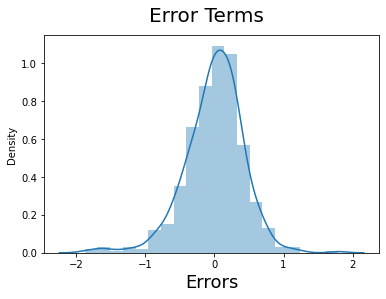

In [1263]:
fig = plt.figure()
sns.distplot((y_train - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)

Question: How did you validate the assumptions of Linear Regression after building the model on the
training set?

Answer:
The most important assumption of a linear regression model is that the errors are independent and normally distributed.-
After we train a Linear Regression model on the given data set, if we run the training data through the same model, the model will generate predictions. Let’s call them y_test_pred. For each predicted value y_test_pred in the vector y_test_pred, there is a corresponding actual value y from the response variable vector y. In the above residual analysis we can the assumption is followed which is that the errors are independent and normally distributed.

# Step 8: Making Predictions

In [1268]:
num_vars=['temp','hum','windspeed','cnt']
df_test[num_vars]= scaler.transform(df_test[num_vars])

Dividing into X_test and y_test

In [1269]:
y_test = df_test.pop('cnt')
X_test = df_test

In [1270]:
# Now let's use our model to make predictions.

# Creating X_test_new dataframe by dropping variables from X_test
X_test_new = X_test[X_train_new.columns]

# Adding a constant variable 
X_test_new = sm.add_constant(X_test_new)

In [1271]:
# Making predictions
y_test_pred = lm1.predict(X_test_new)

# Step 9: Model Evaluation

Text(0, 0.5, 'Predictions')

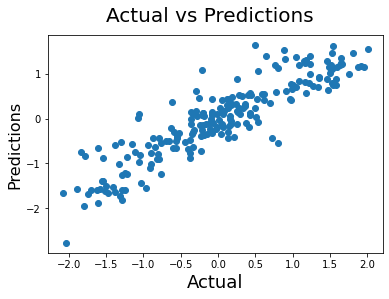

In [1272]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test,y_test_pred)
fig.suptitle('Actual vs Predictions', fontsize=20)              # Plot heading 
plt.xlabel('Actual', fontsize=18)                          # X-label
plt.ylabel('Predictions', fontsize=16)                          # Y-label

In [1273]:
from sklearn.metrics import r2_score
r2_score(y_test, y_test_pred)

0.8075114920782749

Conclusion:¶
The top 5 variables that are seen effecting and benefitting the Bike Rental count are as follows:

1.)Spring season : -0.6842
2.)Temperature : 0.3999
3.)Mist : -0.3647
4.)Sun : 0.2749
5.)working_day : 0.2327

Assumptions of Linear Regression:
The error terms are normally distributed.
The training and testing accuracy are nearly equal hence there is no Overfit/Underfit situation.
The predicted values have linear relationship with the actual values.